In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
file_size_df = pd.read_csv("results/reports/file_sizes.csv")
file_size_df.sample(10)

,SRA_Number,File_Name,File_Path,Process_Name,Read_Label,Size_Byte,Size_KB,Size_MB
17,ERR3909068,ERR3909068.unclassified_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Contamination Output,Read_1,98916538,96598.18,94.33
32,ERR322810,ERR322810_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Repair Read Output,Read_1,48246973,47116.18,46.01
49,ERR3909068,ERR3909068_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Initial Input Files,Read_1,340399458,332421.35,324.63
29,ERR3908889,ERR3908889_2_val_2.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_2,43041532,42032.75,41.05
193,ERR322697,ERR322697_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Initial Input Files,Read_1,28970886,28291.88,27.63
61,SRR11888839,SRR11888839_2_val_2.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_2,13458340,13142.91,12.83
93,ERR322944,ERR322944_1_val_1.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_1,0,0.00,0.00
5,ERR322922,ERR322922.unclassified_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Contamination Output,Read_1,10799017,10545.92,10.30
48,ERR322378,ERR322378.filtered.A.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Mapping Output,Read_1,4328315,4226.87,4.13
140,SRR11888831,SRR11888831.unclassified_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Contamination Output,Read_2,155341001,151700.20,148.14


In [24]:
process_order = [
    "Initial Input Files",
    "Repair Read Output",
    "Quality Control Output",
    "Contamination Output",
    "Mapping Output",
]
# Create a ranking dictionary
order_map = {name: i for i, name in enumerate(process_order)}

# Add a temporary sort key column
file_size_df["_process_order"] = file_size_df["Process_Name"].map(order_map)

ordered_file_size_df = file_size_df.sort_values(
    by=["SRA_Number", "Read_Label", "_process_order"], ascending=[True, True, True]
).drop(columns=["_process_order"])
ordered_file_size_df

,SRA_Number,File_Name,File_Path,Process_Name,Read_Label,Size_Byte,Size_KB,Size_MB
2,ERR322376,ERR322376_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Initial Input Files,Read_1,21907036,21393.59,20.89
121,ERR322376,ERR322376_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Repair Read Output,Read_1,18775382,18335.33,17.91
44,ERR322376,ERR322376_1_val_1.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_1,6823697,6663.77,6.51
142,ERR322376,ERR322376.unclassified_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Contamination Output,Read_1,6229321,6083.32,5.94
109,ERR322376,ERR322376.filtered.A.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Mapping Output,Read_1,6229321,6083.32,5.94
...,...,...,...,...,...,...,...,...
52,SRR11888866,SRR11888866.filtered.A.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Mapping Output,Read_1,57994,56.63,0.06
47,SRR11888866,SRR11888866_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Initial Input Files,Read_2,38587104,37682.72,36.80
112,SRR11888866,SRR11888866_2_val_2.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_2,13545162,13227.70,12.92
198,SRR11888866,SRR11888866.unclassified_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Contamination Output,Read_2,12158147,11873.19,11.59


In [68]:
ordered_file_size_df["diff"] = (
    ordered_file_size_df.groupby(["SRA_Number", "Read_Label"])["Size_MB"]
    .diff(-1)
    .fillna(ordered_file_size_df["Size_MB"])
)
ordered_file_size_df["percentage_diff"] = (
    (
        ordered_file_size_df["diff"]
        / ordered_file_size_df.groupby(["SRA_Number", "Read_Label"])["diff"].transform(
            "sum"
        )
    )
    * 100
).round(2)

ordered_file_size_df["diff_after_process"] = (
    ordered_file_size_df
    .groupby(["SRA_Number", "Read_Label"])["Process_Name"]
    .shift(-1)  # get next row’s process_name within each group
    .fillna("Final remaining size for reassembly")  # if last row
)
ordered_file_size_df

,SRA_Number,File_Name,File_Path,Process_Name,Read_Label,Size_Byte,Size_KB,Size_MB,diff,percentage_diff,diff_after_process
2,ERR322376,ERR322376_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Initial Input Files,Read_1,21907036,21393.59,20.89,2.98,14.27,Repair Read Output
121,ERR322376,ERR322376_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Repair Read Output,Read_1,18775382,18335.33,17.91,11.40,54.57,Quality Control Output
44,ERR322376,ERR322376_1_val_1.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_1,6823697,6663.77,6.51,0.57,2.73,Contamination Output
142,ERR322376,ERR322376.unclassified_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Contamination Output,Read_1,6229321,6083.32,5.94,0.00,0.00,Mapping Output
109,ERR322376,ERR322376.filtered.A.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Mapping Output,Read_1,6229321,6083.32,5.94,5.94,28.43,Final remaining size for reassembly
...,...,...,...,...,...,...,...,...,...,...,...
52,SRR11888866,SRR11888866.filtered.A.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Mapping Output,Read_1,57994,56.63,0.06,0.06,0.16,Final remaining size for reassembly
47,SRR11888866,SRR11888866_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Initial Input Files,Read_2,38587104,37682.72,36.80,23.88,64.89,Quality Control Output
112,SRR11888866,SRR11888866_2_val_2.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_2,13545162,13227.70,12.92,1.33,3.61,Contamination Output
198,SRR11888866,SRR11888866.unclassified_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Contamination Output,Read_2,12158147,11873.19,11.59,11.53,31.33,Mapping Output


In [72]:
pivot_df = ordered_file_size_df.pivot(
    index=["SRA_Number", "Read_Label"],
    columns="diff_after_process",
    values="percentage_diff",
)
pivot_df = pivot_df.rename(
    columns={
        "Repair Read Output": "Size reduced after repair process",
        "Quality Control Output": "Size reduced after Quality Control poccess",
        "Contamination Output": "Size reduced after Contamination Removal poccess",
        "Mapping Output": "Size reduced after Mapping poccess",
        "Remaining file Size for reassembly": "Final remaining size for reassembly",
    }
)
pivoted_difference_order = [
    "Size reduced after repair process",
    "Size reduced after Quality Control poccess",
    "Size reduced after Contamination Removal poccess",
    "Size reduced after Mapping poccess",
    "Final remaining size for reassembly",
]
pivot_df = pivot_df[pivoted_difference_order]

In [73]:
pivot_df = pivot_df.reset_index()
pivot_df

diff_after_process,SRA_Number,Read_Label,Size reduced after repair process,Size reduced after Quality Control poccess,Size reduced after Contamination Removal poccess,Size reduced after Mapping poccess,Final remaining size for reassembly
0,ERR322376,Read_1,14.27,54.57,2.73,0.00,28.43
1,ERR322376,Read_2,14.14,54.65,2.73,0.00,28.48
2,ERR322378,Read_1,14.27,54.88,2.66,0.00,28.19
3,ERR322378,Read_2,14.15,54.96,2.67,0.00,28.23
4,ERR322401,Read_1,14.63,85.37,NaN,NaN,0.00
5,ERR322401,Read_2,14.45,85.55,NaN,NaN,0.00
6,ERR322446,Read_1,14.41,85.59,NaN,NaN,0.00
7,ERR322446,Read_2,14.25,85.75,NaN,NaN,0.00
8,ERR322460,Read_1,32.73,67.27,NaN,NaN,0.00
9,ERR322460,Read_2,14.60,85.40,NaN,NaN,0.00


In [74]:
pivot_df.set_index(["SRA_Number", "Read_Label"])

diff_after_process      Size reduced after repair process  \
SRA_Number  Read_Label                                      
ERR322376   Read_1                                  14.27   
            Read_2                                  14.14   
ERR322378   Read_1                                  14.27   
            Read_2                                  14.15   
ERR322401   Read_1                                  14.63   
            Read_2                                  14.45   
ERR322446   Read_1                                  14.41   
            Read_2                                  14.25   
ERR322460   Read_1                                  32.73   
            Read_2                                  14.60   
ERR322565   Read_1                                  14.65   
            Read_2                                  14.39   
ERR322567   Read_1                                  14.83   
            Read_2                                  14.47   
ERR322579   Read_1                                  14.52   
            Read_2                                  14.49   
ERR322686   Read_1                                  14.47   
            Read_2                                  14.45   
ERR322697   Read_1                                  14.40   
            Read_2                                  14.28   
ERR322717   Read_1                                  14.46   
            Read_2                                  14.34   
ERR322725   Read_1                                  14.62   
            Read_2                                  14.25   
ERR322810   Read_1                                  14.51   
            Read_2                                  14.48   
ERR322832   Read_1                                  14.62   
            Read_2                                  14.52   
ERR322839   Read_1                                  14.63   
            Read_2                                  14.59   
ERR322856   Read_1                                  14.70   
            Read_2                                  14.62   
ERR322922   Read_1                                  14.56   
            Read_2                                  14.53   
ERR322944   Read_1                                  14.62   
            Read_2                                  14.39   
ERR3908707  Read_1                                    NaN   
            Read_2                                    NaN   
ERR3908889  Read_1                                    NaN   
            Read_2                                    NaN   
ERR3909068  Read_1                                    NaN   
            Read_2                                    NaN   
ERR3909082  Read_1                                    NaN   
            Read_2                                    NaN   
SRR11888831 Read_1                                    NaN   
            Read_2                                    NaN   
SRR11888839 Read_1                                    NaN   
            Read_2                                    NaN   
SRR11888866 Read_1                                    NaN   
            Read_2                                    NaN   

diff_after_process      Size reduced after Quality Control poccess  \
SRA_Number  Read_Label                                               
ERR322376   Read_1                                           54.57   
            Read_2                                           54.65   
ERR322378   Read_1                                           54.88   
            Read_2                                           54.96   
ERR322401   Read_1                                           85.37   
            Read_2                                           85.55   
ERR322446   Read_1                                           85.59   
            Read_2                                           85.75   
ERR322460   Read_1                                           67.27   
            Read_2                                       

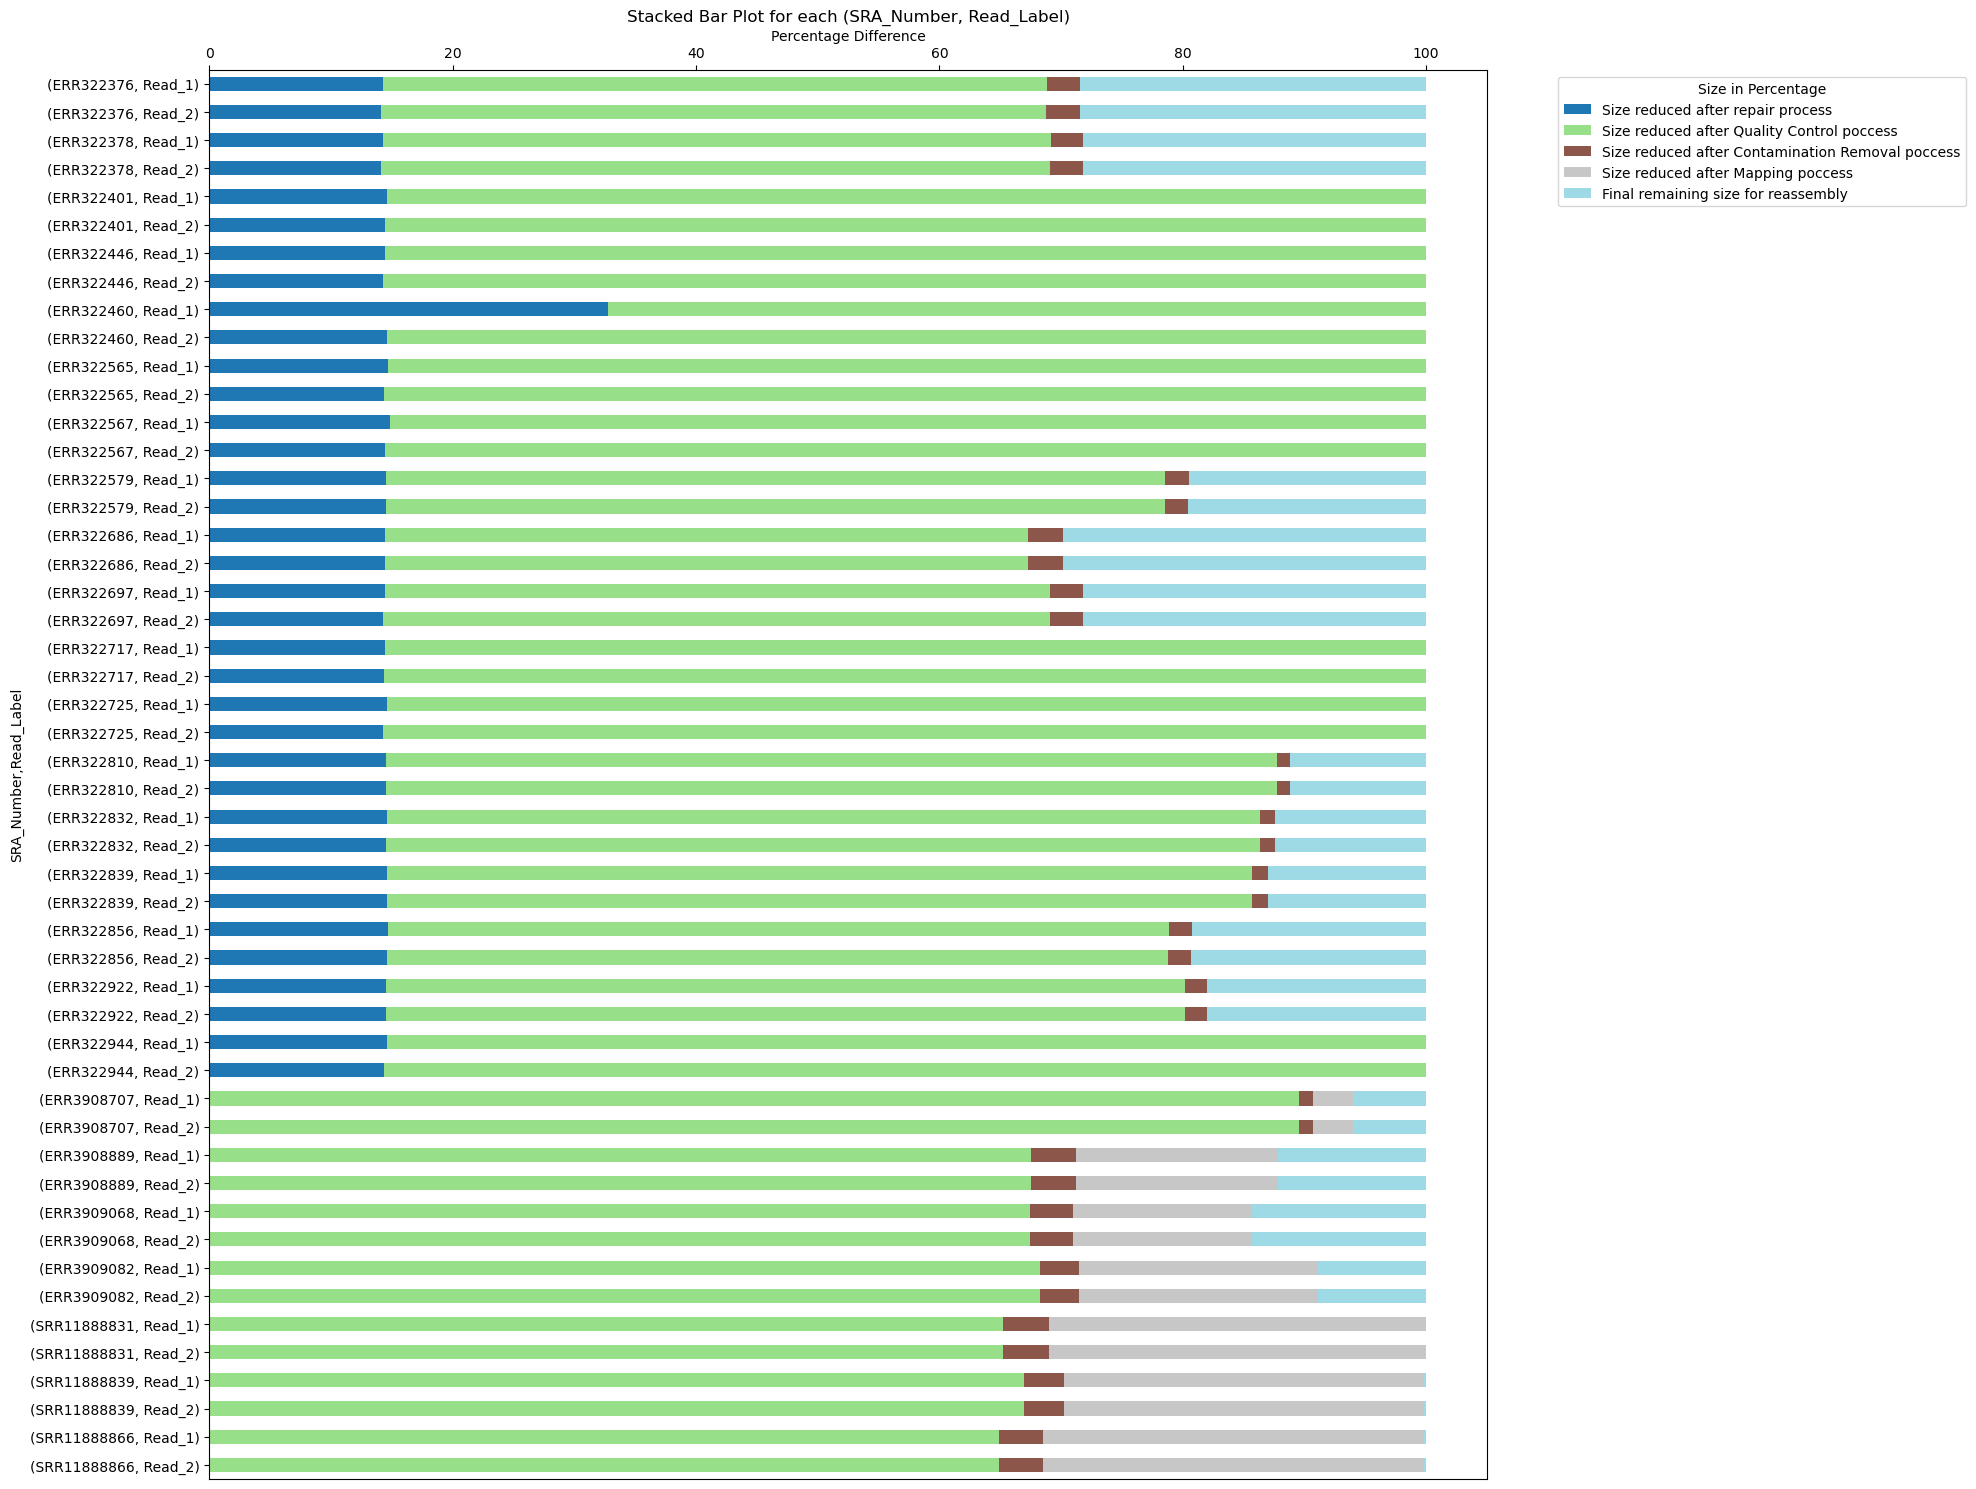

In [95]:

# Set plot size
# plt.figure(figsize=(12, 6))

# Plot stacked bar chart
ax = pivot_df.set_index(["SRA_Number", "Read_Label"]).plot(
    kind="barh",
    stacked=True,
    figsize=(20, 15),
    colormap="tab20"
)
ax.invert_yaxis()
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.xlabel("Percentage Difference")
plt.title("Stacked Bar Plot for each (SRA_Number, Read_Label)")
# plt.xticks(rotation=45, ha="right")
plt.legend(title="Size in Percentage", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
